In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

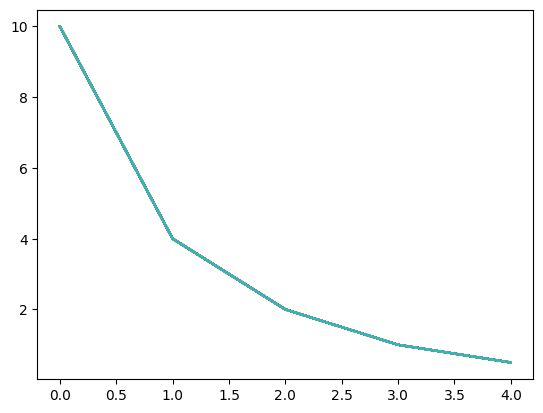

In [2]:
N_p = 50 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

In [3]:
y0

array([[10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,  1. ,  0.5],
       [10. ,  4. ,  2. ,

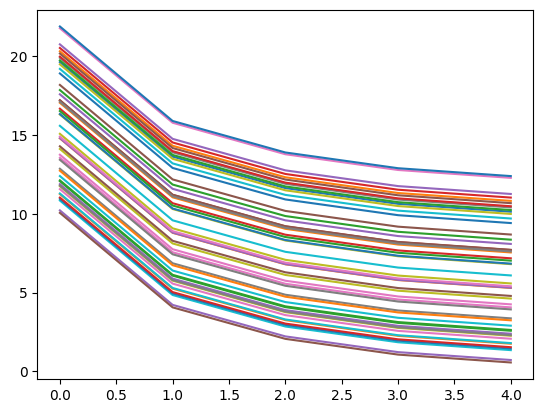

In [4]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

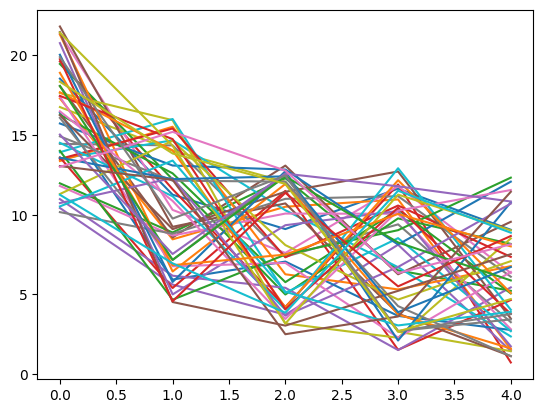

In [5]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [6]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   250       Method:               REML     
No. Groups:         50        Scale:                0.0000   
Min. group size:    5         Log-Likelihood:       1787.3933
Max. group size:    5         Converged:            Yes      
Mean group size:    5.0                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.587     0.221       70.380 0.000 15.153 16.021
Week[T.T1]  -6.000     0.000 -2320843.700 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -3094458.266 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -3481265.549 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -3674669.191 0.000 -9.500 -9.500
Patient Var  2.453 19165.526                                 
=============================================================

"""

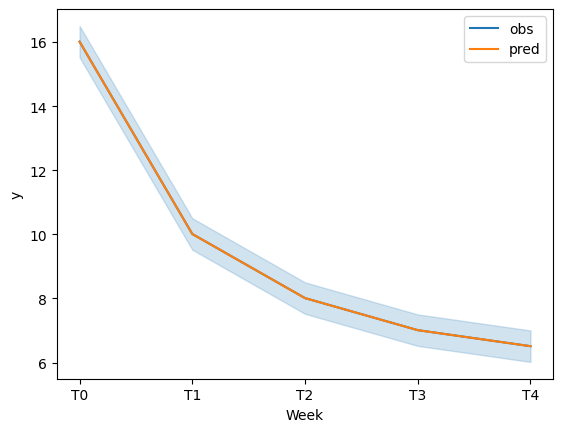

In [18]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [19]:
kill = np.random.randint(low=0, high=50, size=20)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   235       Method:               REML     
No. Groups:         50        Scale:                0.0000   
Min. group size:    4         Log-Likelihood:       1637.2022
Max. group size:    5         Converged:            Yes      
Mean group size:    4.7                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   16.012     0.227       70.670 0.000 15.568 16.456
Week[T.T1]  -6.000     0.000 -2023167.505 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -2697556.673 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -3034751.257 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -3203348.549 0.000 -9.500 -9.500
Patient Var  2.567 20488.992                                 
=============================================================

"""

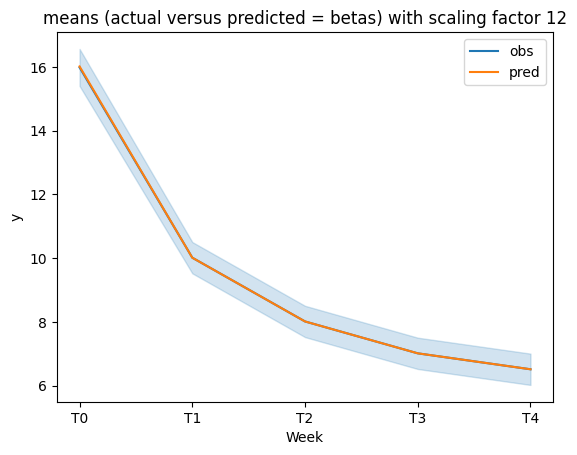

In [20]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

In [21]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

# log transform it
#df_mult['y'] = np.log(df_mult['y'])

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient', re_formula = '~Week').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Mixed Linear Model Regression Results
=========================================================================
Model:                  MixedLM       Dependent Variable:       y        
No. Observations:       250           Method:                   REML     
No. Groups:             50            Scale:                    8.2275   
Min. group size:        5             Log-Likelihood:           -665.6156
Max. group size:        5             Converged:                Yes      
Mean group size:        5.0                                              
-------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------
Intercept                    16.575    0.509  32.595 0.000  15.579 17.572
Week[T.T1]                   -6.752    0.766  -8.817 0.000  -8.252 -5.251
Week[T.T2]                   -8.415    0.706 -11.922 0.000  -9.798 -7.032
Week[T.T3]                   -9.300    0.668 -13.923 0.000 -10.609 -7.991
Week[T.T4]                  -10.199    0.708 -14.406 0.000 -11.587 -8.812
Patient Var                   4.702                                      
Patient x Week[T.T1] Cov     -6.301                                      
Week[T.T1] Var               12.865                                      
Patient x Week[T.T2] Cov     -3.701                                      
Week[T.T1] x Week[T.T2] Cov   1.273                                      
Week[T.T2] Var                8.457                                      
Patient x Week[T.T3] Cov     -3.526                                      
Week[T.T1] x Week[T.T3] Cov   5.508                                      
Week[T.T2] x Week[T.T3] Cov   2.769                                      
Week[T.T3] Var                5.853                                      
Patient x Week[T.T4] Cov     -4.606                                      
Week[T.T1] x Week[T.T4] Cov   4.903                                      
Week[T.T2] x Week[T.T4] Cov   1.659                                      
Week[T.T3] x Week[T.T4] Cov   2.528                                      
Week[T.T4] Var                8.607                                      
=========================================================================

"""

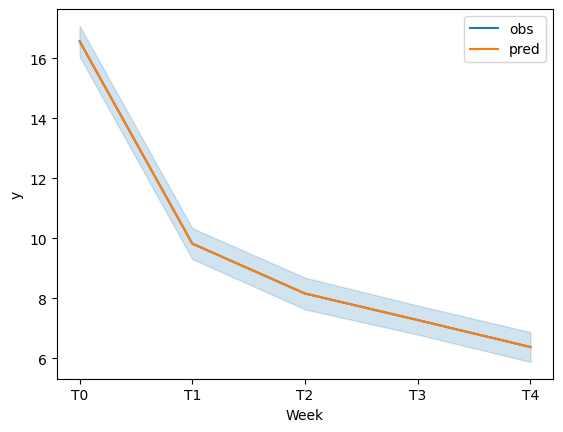

In [22]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [23]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient', re_formula = '~Week').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Mixed Linear Model Regression Results
=========================================================================
Model:                  MixedLM       Dependent Variable:       y        
No. Observations:       235           Method:                   REML     
No. Groups:             50            Scale:                    8.2609   
Min. group size:        4             Log-Likelihood:           -624.1107
Max. group size:        5             Converged:                Yes      
Mean group size:        4.7                                              
-------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------
Intercept                    16.456    0.598  27.517 0.000  15.284 17.628
Week[T.T1]                   -6.633    0.825  -8.038 0.000  -8.250 -5.015
Week[T.T2]                   -8.296    0.803 -10.325 0.000  -9.871 -6.721
Week[T.T3]                   -9.181    0.735 -12.495 0.000 -10.621 -7.741
Week[T.T4]                  -10.080    0.723 -13.944 0.000 -11.497 -8.663
Patient Var                   4.236                                      
Patient x Week[T.T1] Cov     -5.720                                      
Week[T.T1] Var               12.136                                      
Patient x Week[T.T2] Cov     -4.443                                      
Week[T.T1] x Week[T.T2] Cov   1.901                                      
Week[T.T2] Var               10.373                                      
Patient x Week[T.T3] Cov     -2.927                                      
Week[T.T1] x Week[T.T3] Cov   4.793                                      
Week[T.T2] x Week[T.T3] Cov   3.378                                      
Week[T.T3] Var                5.085                                      
Patient x Week[T.T4] Cov     -2.197                                      
Week[T.T1] x Week[T.T4] Cov   2.378                                      
Week[T.T2] x Week[T.T4] Cov   0.458                                      
Week[T.T3] x Week[T.T4] Cov  -0.015                                      
Week[T.T4] Var                4.223                                      
=========================================================================

"""

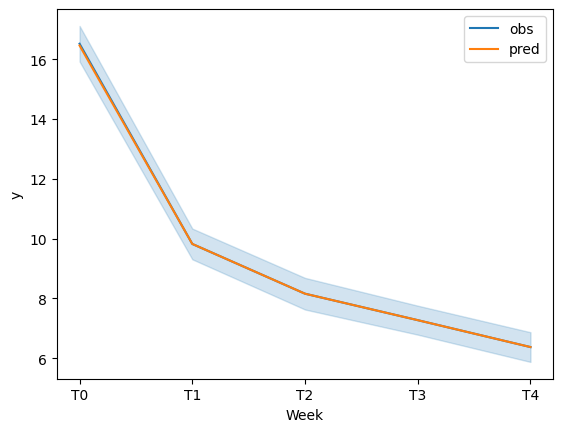

In [24]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)